# BERTopic-Based Song Recommendation System

This notebook implements a comprehensive BERTopic-based music recommendation system as outlined in the research plan. It includes:

1. **Data preprocessing** (adapted from LDA pipeline)
2. **BERTopic model training** with transformer embeddings
3. **LLM-assisted topic labeling** using GPT for interpretable topic names
4. **Song/Artist similarity calculation** using cosine similarity on topic distributions
5. **Diversity-aware recommendations** using Maximal Marginal Relevance (MMR)
6. **Comprehensive evaluation** and visualization tools

## 🎯 Key Features:
- **Transformer-based embeddings** for better semantic understanding
- **Automatic topic discovery** with HDBSCAN clustering
- **Human-readable topic labels** generated via LLM prompts
- **Artist-level aggregation** of topic distributions
- **Diversity re-ranking** to avoid echo chambers
- **Interactive visualizations** and analysis tools

In [1]:
# Core imports for BERTopic and preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import pickle
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# BERTopic and related libraries
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# For preprocessing (adapted from LDA notebook)
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
import re

# For similarity and recommendations
from scipy.spatial.distance import cosine
from difflib import SequenceMatcher

# For LLM topic labeling with LangChain and OpenAI
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage
from langchain.prompts import PromptTemplate
import openai
from dotenv import load_dotenv

# Download necessary NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
tokenizer = RegexpTokenizer(r"[A-Za-z]+(?:'[A-Za-z]*)?")

print("📦 All libraries imported successfully!")
print("🚀 Ready to build BERTopic-based song recommendation system!")
print("🤖 LangChain + OpenAI integration ready for topic labeling!")

# Note: Make sure to set your OpenAI API key
load_dotenv(override=True)  # Load environment variables from .env file
openai_api_key = os.getenv("OPENAI_API_KEY")

📦 All libraries imported successfully!
🚀 Ready to build BERTopic-based song recommendation system!
🤖 LangChain + OpenAI integration ready for topic labeling!


In [ ]:
# Load and inspect the data
import pandas as pd
df = pd.read_csv('../Lyrics_extraction/scraped_lyrics_no_metadata.csv', encoding='utf-8')

print(f"📊 Dataset Overview:")
print(f"   Songs: {len(df):,}")
print(f"   Artists: {df['artist'].nunique():,}")
print(f"   Columns: {list(df.columns)}")

# Display sample data
print(f"\n🎵 Sample songs:")
sample_df = df.head(3)[['artist', 'song_title']].reset_index(drop=True)
for i, row in sample_df.iterrows():
    print(f"   {i+1}. {row['artist']} - {row['song_title']}")

# Check for missing values
print(f"\n🔍 Data quality check:")
print(f"   Missing lyrics: {df['lyrics'].isna().sum()}")
print(f"   Empty lyrics: {(df['lyrics'].str.len() < 50).sum()}")

print(f"\n📝 Average lyrics length: {df['lyrics'].str.len().mean():.0f} characters")
df.head()

📊 Dataset Overview:
   Songs: 2,595
   Artists: 1,672
   Columns: ['Index', 'artist', 'song_title', 'Mood', 'lyrics']

🎵 Sample songs:
   1. Usher - There Goes My Baby
   2. Da'Ville - On My Mind
   3. Rihanna - Rockstar 101 

🔍 Data quality check:
   Missing lyrics: 122
   Empty lyrics: 6

📝 Average lyrics length: 1153 characters


,Index,artist,song_title,Mood,lyrics
0,ML1,Usher,There Goes My Baby,relaxed,"[Intro]\nYeah, right\nUsher, baby\nOkay\nYeah ..."
1,ML2,Da'Ville,On My Mind,relaxed,Ahhhhhhhh\nYou're om my mind\nYea\n\nVerse1\nI...
2,ML3,Rihanna,Rockstar 101,relaxed,"[Intro]\nI told ya, I told ya\nI told ya baby,..."
3,ML4,J. Holiday,Bed,relaxed,[Written by The-Dream and Los Da Mystro]\n\n[I...
4,ML5,Morgan Heritage,Don't Haffi Dread,angry,"Yeah, yeah, yeah - ragga so ragga\n\nYou don't..."


In [3]:
# ===== PREPROCESSING FUNCTIONS (Adapted from LDA notebook) =====



def clean_lyrics_for_bertopic(text):
    """
    Clean lyrics specifically for BERTopic processing
    BERTopic works better with sentences/phrases rather than individual tokens
    """
    if pd.isna(text) or not text:
        return ""
    
    text = str(text)
    
    # Remove structural markers like [Chorus], [Verse], etc.
    text = re.sub(r'\[.*?\]', '', text)
    
    # Clean up whitespace and newlines
    text = re.sub(r'\n+', ' ', text)  # Replace newlines with spaces
    text = re.sub(r'\s+', ' ', text)  # Normalize whitespace    
    
    return text.strip()

def preprocess_for_bertopic(texts, min_length=0, verbose=True):
    """
    Preprocess lyrics corpus for BERTopic
    """
    if verbose:
        print("🔄 Preprocessing lyrics for BERTopic...")
    
    processed_docs = []
    skipped_count = 0
    
    for i, text in enumerate(texts):
        cleaned_text = clean_lyrics_for_bertopic(text)
        
        processed_docs.append(cleaned_text)
     
        if verbose and (i + 1) % 500 == 0:
            print(f"   Processed {i + 1}/{len(texts)} documents")
    
    if verbose:
        valid_docs = len([doc for doc in processed_docs if doc])
        print(f"✅ Preprocessing complete:")
        print(f"   Valid documents: {valid_docs:,}")
        print(f"   Skipped (too short): {skipped_count:,}")
        print(f"   Success rate: {valid_docs/len(texts)*100:.1f}%")
    
    return processed_docs

# Apply preprocessing
print("🧹 Cleaning lyrics for BERTopic analysis...")
df['lyrics_cleaned'] = preprocess_for_bertopic(df['lyrics'])

# Filter out empty documents
initial_count = len(df)
df = df[df['lyrics_cleaned'].str.len() > 0].reset_index(drop=True)
print(f"📊 Filtered dataset: {len(df):,} songs (removed {initial_count - len(df)} invalid entries)")

# Show sample cleaned lyrics
print(f"\n📝 Sample cleaned lyrics:")
sample_text = df['lyrics_cleaned'].iloc[0][:300]
print(f"   {sample_text}...")

🧹 Cleaning lyrics for BERTopic analysis...
🔄 Preprocessing lyrics for BERTopic...
   Processed 500/2595 documents
   Processed 1000/2595 documents
   Processed 1500/2595 documents
   Processed 2000/2595 documents
   Processed 2500/2595 documents
✅ Preprocessing complete:
   Valid documents: 2,473
   Skipped (too short): 0
   Success rate: 95.3%
📊 Filtered dataset: 2,473 songs (removed 122 invalid entries)

📝 Sample cleaned lyrics:
   Yeah, right Usher, baby Okay Yeah man Right (Turn the lights off) There goes my baby (Ooh, girl, look at you) You don't know how good it feels to call you my girl There goes my baby (Yeah) Loving everything you do Ooh, girl, look at you Bet you ain't know that I be checking you out when you be putti...


In [4]:
# ===== TOPIC MODELING CONFIGURATION =====
import bertopic
import bertopic.backend
from sklearn.cluster import KMeans
from torch import mul
print("🤖 Configuring BERTopic components...")

# 1. Sentence Transformer for embeddings
print("   Loading sentence transformer model...")
embedding_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')
print(f"   ✅ Loaded: {embedding_model.get_sentence_embedding_dimension()}D embeddings")

# 2. UMAP for dimensionality reduction
print("   Configuring UMAP for dimensionality reduction...")
umap_model = UMAP(
    n_neighbors=15,        # Smaller for more local structure (try 5-15)
    n_components=15,       # Try higher dimensionality (5-15)
    min_dist=0.00,         # Keep this low
    metric='cosine',
    random_state=42
)
print("   ✅ UMAP configured")

# 3. HDBSCAN for clustering
print("   Configuring HDBSCAN(KMeans) for clustering...")
hdbscan_model = HDBSCAN(
    min_cluster_size=2,             # Smaller value to allow smaller clusters
    min_samples=2,                  # Lower value to make it easier to form clusters
    metric='euclidean',             # Keep the same distance metric
    cluster_selection_method='eom',  # Use leaf method for more fine-grained clusters
    # cluster_selection_epsilon=0.1,   # Lower epsilon for less merging
    prediction_data=True,           # Keep prediction capability
    allow_single_cluster=True,      # Allow single clusters if appropriate
    alpha=1.0                       # Default alpha setting
)

kmeans_model = KMeans(
    n_clusters=10,           # Set your desired number of topics
    random_state=100,         # For reproducibility
    n_init='auto',
    init='k-means++',  # Use k-means++ initialization for better convergence
)
print("   ✅ HDBSCAN configured")

# 4. Vectorizer for topic representation (simplified to avoid parameter conflicts)
print("   Configuring CountVectorizer...")
vectorizer_model = CountVectorizer(
    ngram_range=(1, 3),     # Include bigrams for better context
    stop_words="english",
    # min_df=5,               # Filter out very rare terms
    # max_df=0.85,            # Filter out extremely common terms
)
print("   ✅ CountVectorizer configured")
bertopic.backend.languages
# 5. Create BERTopic instance
print("   Creating BERTopic model...")
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    language="english", #will be ignored if embedding_model is provided
    embedding_model=embedding_model, 
    # Smaller topics allowed
    nr_topics=10       # Let BERTopic determine optimal number
)

print("   ✅ BERTopic model ready for training!")

print(f"\n📋 Model Configuration Summary:")
print(f"   Embedding: {embedding_model.get_sentence_embedding_dimension()}D sentence-transformers")
print(f"   UMAP: {umap_model.n_components}D reduction")
print(f"   Clustering: HDBSCAN")
print(f"   Vectorizer: {vectorizer_model.ngram_range} n-grams, max_features={vectorizer_model.max_features}")
print(f"   Vocabulary filtering: default settings (no min_df/max_df constraints)")

🤖 Configuring BERTopic components...
   Loading sentence transformer model...
   ✅ Loaded: 512D embeddings
   Configuring UMAP for dimensionality reduction...
   ✅ UMAP configured
   Configuring HDBSCAN(KMeans) for clustering...
   ✅ HDBSCAN configured
   Configuring CountVectorizer...
   ✅ CountVectorizer configured
   Creating BERTopic model...
   ✅ BERTopic model ready for training!

📋 Model Configuration Summary:
   Embedding: 512D sentence-transformers
   UMAP: 15D reduction
   Clustering: HDBSCAN
   Vectorizer: (1, 3) n-grams, max_features=None
   Vocabulary filtering: default settings (no min_df/max_df constraints)


In [16]:
# ===== TRAIN BERTOPIC MODEL =====

print(f"🚀 Training BERTopic model on song lyrics...")
print(f"📊 Training on {len(df)} songs")

# Prepare documents
documents = df['lyrics_cleaned'].tolist()

print(f"\n⏳ This may take several minutes for large datasets...")
print("🔄 Training in progress...")

# Train BERTopic model
topics, probabilities = topic_model.fit_transform(documents)
# topic_model.reduce_outliers(documents=documents, topics= topics,probabilities= probabilities, strategy="c-tf-idf")
print(f"\n✅ BERTopic training completed!")
print(f"📊 Results:")
print(f"   Total topics discovered: {len(set(topics))}")
print(f"   Documents assigned to topics: {len([t for t in topics if t != -1])}")
print(f"   Outlier documents (topic -1): {len([t for t in topics if t == -1])}")

# Get topic info
topic_info = topic_model.get_topic_info()
print(f"\n🏷️ Topic size distribution:")
for i, row in topic_info.head(10).iterrows():
    if row['Topic'] != -1:
        topic_words = [word.split('_')[0] for word in row['Representation'][:5]]
        print(f"   Topic {row['Topic']:2d}: {row['Count']:4d} songs - {', '.join(topic_words)}")

# Store results in dataframe
df['topic'] = topics
df['topic_probability'] = probabilities.max(axis=1) if probabilities is not None else [0.0] * len(topics)

print(f"\n📈 Assignment statistics:")
print(f"   Average topic confidence: {df['topic_probability'].mean():.3f}")
print(f"   Songs with high confidence (>0.5): {(df['topic_probability'] > 0.5).sum()}")

print(f"\n🎉 BERTopic training complete!")

2025-07-05 18:13:51,962 - BERTopic - Embedding - Transforming documents to embeddings.


🚀 Training BERTopic model on song lyrics...
📊 Training on 2473 songs

⏳ This may take several minutes for large datasets...
🔄 Training in progress...


Batches: 100%|██████████| 78/78 [02:26<00:00,  1.87s/it]
2025-07-05 18:16:18,083 - BERTopic - Embedding - Completed ✓
2025-07-05 18:16:18,085 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-05 18:16:40,568 - BERTopic - Dimensionality - Completed ✓
2025-07-05 18:16:40,570 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-05 18:17:14,127 - BERTopic - Cluster - Completed ✓
2025-07-05 18:17:14,129 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-07-05 18:17:17,362 - BERTopic - Representation - Completed ✓
2025-07-05 18:17:17,370 - BERTopic - Topic reduction - Reducing number of topics
2025-07-05 18:17:17,416 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-05 18:17:20,280 - BERTopic - Representation - Completed ✓
2025-07-05 18:17:20,289 - BERTopic - Topic reduction - Reduced number of topics from 327 to 10



✅ BERTopic training completed!
📊 Results:
   Total topics discovered: 10
   Documents assigned to topics: 1836
   Outlier documents (topic -1): 637

🏷️ Topic size distribution:
   Topic  0: 1695 songs - love, oh, don, love love, know
   Topic  1:   95 songs - christmas, merry, merry christmas, happy, blue
   Topic  2:   21 songs - change, sun, change good, good, good change
   Topic  3:    9 songs - que, la, el, su, se
   Topic  4:    4 songs - respect, respect respect, na, na na, respect don
   Topic  5:    3 songs - blind blind, blind blind blind, blind, dog, shake
   Topic  6:    3 songs - fame, fame fame, fame fame fame, fame fame doin, fame doin
   Topic  7:    3 songs - man, love love, love love love, love, man come
   Topic  8:    3 songs - runnin scared, gotta home tonight, gotta home, scared, home tonight

📈 Assignment statistics:
   Average topic confidence: 0.729
   Songs with high confidence (>0.5): 1832

🎉 BERTopic training complete!


📊 Analyzing discovered topics...
Topic Info Shape: (10, 5)

🏷️ Topic Distribution:
   Valid topics: 9
   Outliers (topic -1): 637

🔝 Top 10 Topics by Size:
   Topic  0 (1695 songs): love, oh, don, love love, know, baby, like, just
      • Usher - There Goes My Baby
      • Da'Ville - On My Mind
      • Rihanna - Rockstar 101 

   Topic  1 (  95 songs): christmas, merry, merry christmas, happy, blue, birthday, wish, wish merry christmas
      • The Beatles - Birthday
      • Ronnie Milsap - Happy, Happy Birthday Baby
      • Jose Feliciano - Feliz Navidad

   Topic  2 (  21 songs): change, sun, change good, good, good change, change change good, change change, good change good
      • Kenny Chesney - When The Sun Goes Down 
      • Sheryl Crow - A Change Would Do You Good
      • Hot Snakes - Braintrust

   Topic  3 (   9 songs): que, la, el, su, se, dinero, yo, rodar
      • George Strait - El Rey
      • Los Cadetes De Linares - Las Tres Tumbas
      • Chalino Sanchez - Baraja De Oro 

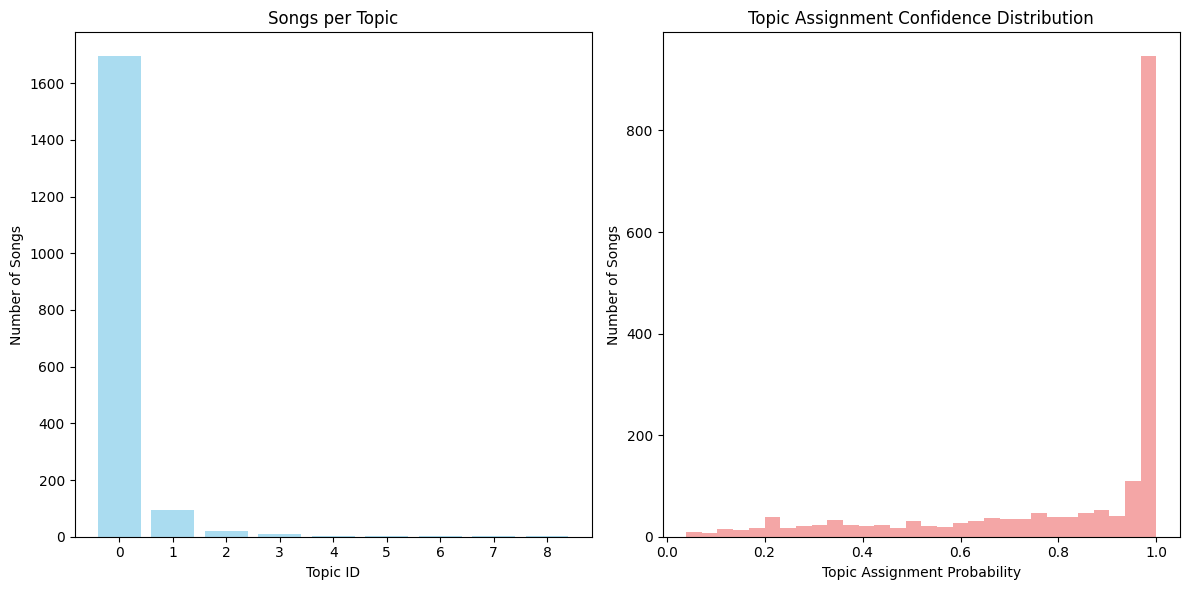

📊 Summary Statistics:
   Total unique topics: 9
   Average songs per topic: 204.0
   Largest topic size: 1695
   Smallest topic size: 3


In [6]:
# ===== TOPIC ANALYSIS AND VISUALIZATION =====

print("📊 Analyzing discovered topics...")

# Get detailed topic information
topic_info = topic_model.get_topic_info()
print(f"Topic Info Shape: {topic_info.shape}")

# Analyze topic distribution
topic_counts = df['topic'].value_counts().sort_index()
print(f"\n🏷️ Topic Distribution:")
print(f"   Valid topics: {len(topic_counts[topic_counts.index != -1])}")
print(f"   Outliers (topic -1): {topic_counts.get(-1, 0)}")

# Show top topics with their representative words
print(f"\n🔝 Top 10 Topics by Size:")
valid_topics = topic_info[topic_info['Topic'] != -1].head(10)

for _, row in valid_topics.iterrows():
    topic_id = row['Topic']
    count = row['Count']
    # Get clean topic words (remove scores)
    topic_words = [word.split('_')[0] for word in row['Representation'][:8]]
    print(f"   Topic {topic_id:2d} ({count:4d} songs): {', '.join(topic_words)}")
    
    # Show sample songs for this topic
    sample_songs = df[df['topic'] == topic_id].head(3)
    for _, song in sample_songs.iterrows():
        print(f"      • {song['artist']} - {song['song_title']}")
    print()

# Visualize topic sizes
plt.figure(figsize=(12, 6))
valid_topic_counts = topic_counts[topic_counts.index != -1]

plt.subplot(1, 2, 1)
plt.bar(range(len(valid_topic_counts)), valid_topic_counts.values, color='skyblue', alpha=0.7)
plt.xlabel('Topic ID')
plt.ylabel('Number of Songs')
plt.title('Songs per Topic')
plt.xticks(range(len(valid_topic_counts)), valid_topic_counts.index)

plt.subplot(1, 2, 2)
plt.hist(df[df['topic'] != -1]['topic_probability'], bins=30, color='lightcoral', alpha=0.7)
plt.xlabel('Topic Assignment Probability')
plt.ylabel('Number of Songs')
plt.title('Topic Assignment Confidence Distribution')

plt.tight_layout()
plt.show()

print(f"📊 Summary Statistics:")
print(f"   Total unique topics: {len(valid_topic_counts)}")
print(f"   Average songs per topic: {valid_topic_counts.mean():.1f}")
print(f"   Largest topic size: {valid_topic_counts.max()}")
print(f"   Smallest topic size: {valid_topic_counts.min()}")

In [7]:
# ===== LLM-ASSISTED TOPIC LABELING WITH LANGCHAIN + OPENAI =====

def generate_topic_labels_with_llm(topic_model, max_topics=20):
    """
    Generate human-readable topic labels using LangChain + OpenAI GPT
    """
    print("🤖 Generating human-readable topic labels with LLM...")
    
    # Check if OpenAI API key is set
    if not os.getenv("OPENAI_API_KEY"):
        print("⚠️ OpenAI API key not found. Please set OPENAI_API_KEY environment variable.")
        print("   Example: os.environ['OPENAI_API_KEY'] = 'your-api-key-here'")
        return generate_fallback_labels(topic_model, max_topics)
    
    # Initialize LangChain OpenAI client
    try:
        llm = ChatOpenAI(
            model="gpt-4o",
            temperature=0.3,
            max_tokens=100,
            api_key=openai_api_key,
        )
        print("   ✅ Connected to OpenAI GPT-3.5-turbo")
    except Exception as e:
        print(f"   ❌ Failed to connect to OpenAI: {e}")
        return generate_fallback_labels(topic_model, max_topics)
    
    # Create prompt template for topic labeling
    prompt_template = PromptTemplate.from_template(
        """You are a music expert analyzing song lyrics topics. 
        
        Here are the top 10 most representative words for a music topic:
        {topic_words}
        
        Based on these words, please provide:
        1. A concise, human-readable topic label (2-4 words)
        2. A brief explanation of why this label fits
        
        Topic Label:"""
    )
    
    topic_labels = {}
    topic_info = topic_model.get_topic_info()
    
    # Process top topics (excluding outliers)
    valid_topics = topic_info[topic_info['Topic'] != -1].head(max_topics)
    
    print(f"   Processing {len(valid_topics)} topics...")
    
    for i, row in valid_topics.iterrows():
        topic_id = row['Topic']
        topic_words = [word.split('_')[0] for word in row['Representation'][:20]]
        
        try:
            # Create prompt
            prompt = prompt_template.format(topic_words=", ".join(topic_words))
            
            # Get LLM response
            messages = [
                SystemMessage(content="You are a helpful music expert that creates concise topic labels."),
                HumanMessage(content=prompt)
            ]
            
            response = llm(messages)
            
            # Extract the label (first line of response)
            label = response.content.strip().split('\n')[0]
            
            # Clean up the label
            if label.startswith("Topic Label:"):
                label = label.replace("Topic Label:", "").strip()
            
            # Ensure label is not too long
            if len(label) > 50:
                label = label[:47] + "..."
            
            topic_labels[topic_id] = {
                'label': label,
                'words': topic_words,
                'confidence': 'llm_generated',
                'raw_response': response.content
            }
            
            print(f"   Topic {topic_id:2d}: '{label}'")
            
        except Exception as e:
            print(f"   ❌ Failed to generate label for topic {topic_id}: {e}")
            # Fallback to manual labeling for this topic
            fallback_label = generate_manual_label(topic_words)
            topic_labels[topic_id] = {
                'label': fallback_label,
                'words': topic_words,
                'confidence': 'fallback'
            }
            print(f"   Topic {topic_id:2d}: '{fallback_label}' (fallback)")
    
    return topic_labels

def generate_fallback_labels(topic_model, max_topics=20):
    """
    Generate topic labels using rule-based approach when LLM is not available
    """
    print("🔄 Using rule-based topic labeling (LLM not available)...")
    
    topic_labels = {}
    topic_info = topic_model.get_topic_info()
    
    # Process top topics (excluding outliers)
    valid_topics = topic_info[topic_info['Topic'] != -1].head(max_topics)
    
    for _, row in valid_topics.iterrows():
        topic_id = row['Topic']
        topic_words = [word.split('_')[0] for word in row['Representation'][:10]]
        
        # Generate rule-based label
        label = generate_manual_label(topic_words)
        topic_labels[topic_id] = {
            'label': label,
            'words': topic_words,
            'confidence': 'rule_based'
        }
        
        print(f"   Topic {topic_id:2d}: '{label}'")
    
    return topic_labels

def generate_manual_label(words):
    """
    Generate topic labels based on word patterns (rule-based approach)
    """
    words_str = ' '.join(words).lower()
    
    # Common music topic patterns
    if any(word in words_str for word in ['love', 'heart', 'baby', 'girl', 'boy']):
        return "Love & Romance"
    elif any(word in words_str for word in ['party', 'night', 'dance', 'club', 'fun']):
        return "Party & Nightlife"
    elif any(word in words_str for word in ['money', 'rich', 'cash', 'gold', 'success']):
        return "Success & Wealth"
    elif any(word in words_str for word in ['life', 'world', 'people', 'time', 'way']):
        return "Life Philosophy"
    elif any(word in words_str for word in ['home', 'family', 'mother', 'father', 'back']):
        return "Family & Home"
    elif any(word in words_str for word in ['feel', 'pain', 'hurt', 'cry', 'sad']):
        return "Emotional Pain"
    elif any(word in words_str for word in ['music', 'song', 'sing', 'beat', 'sound']):
        return "Music & Performance"
    elif any(word in words_str for word in ['friend', 'together', 'people', 'us', 'we']):
        return "Friendship & Unity"
    elif any(word in words_str for word in ['dream', 'hope', 'future', 'wish', 'want']):
        return "Dreams & Aspirations"
    elif any(word in words_str for word in ['city', 'street', 'road', 'car', 'drive']):
        return "Urban Life & Travel"
    else:
        return f"Theme: {words[0].title()}"

# Generate topic labels using LLM
topic_labels = generate_topic_labels_with_llm(topic_model, max_topics=15)

print(f"\n✅ Generated labels for {len(topic_labels)} topics")

# Show summary of labeling methods used
llm_labels = sum(1 for label in topic_labels.values() if label['confidence'] == 'llm_generated')
fallback_labels = sum(1 for label in topic_labels.values() if label['confidence'] in ['fallback', 'rule_based'])

print(f"\n📊 Labeling Summary:")
print(f"   LLM-generated labels: {llm_labels}")
print(f"   Rule-based labels: {fallback_labels}")

if llm_labels > 0:
    print(f"\n🎯 LLM-generated topic labels are ready!")
    print(f"   To improve results, consider adjusting the prompt template or using GPT-4")
else:
    print(f"\n💡 To use LLM labeling, set your OpenAI API key:")
    print(f"   os.environ['OPENAI_API_KEY'] = 'your-api-key-here'")

🤖 Generating human-readable topic labels with LLM...
   ✅ Connected to OpenAI GPT-3.5-turbo
   Processing 9 topics...


C:\Users\Admin\AppData\Local\Temp\ipykernel_45236\513407598.py:64: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = llm(messages)


   Topic  0: 'Romantic Pop Anthem'
   Topic  1: 'Christmas and Holiday Wishes'
   Topic  2: 'Positive Transformation'
   Topic  3: 'Family and Wealth Struggles'
   Topic  4: 'Respect and Empowerment'
   Topic  5: 'Animal Metaphors in Blindness'
   Topic  6: 'Obsession with Fame'
   Topic  7: 'Romantic Conflict Resolution'
   Topic  8: 'Fear of Returning Home'

✅ Generated labels for 9 topics

📊 Labeling Summary:
   LLM-generated labels: 9
   Rule-based labels: 0

🎯 LLM-generated topic labels are ready!
   To improve results, consider adjusting the prompt template or using GPT-4


In [8]:
# ===== TOPIC DISTRIBUTION EXTRACTION =====

def get_song_topic_distribution(topic_model, documents, topics, probabilities):
    """
    Extract topic distributions for each song
    BERTopic assigns each document to one topic, but we can get soft distributions
    """
    print("📊 Extracting topic distributions for songs...")
    
    num_topics = len(set(topics)) - (1 if -1 in topics else 0)  # Exclude outlier topic
    # num_topics = len(set(topics))
    topic_distributions = []
    
    # For each document, create a distribution vector
    for i, (topic, prob_array) in enumerate(zip(topics, probabilities)):
        if topic == -1:  # Outlier documents
            # Create uniform low-confidence distribution
            distribution = np.ones(num_topics) / num_topics * 0.1
        else:
            # Use the probability distribution from BERTopic
            if prob_array is not None:
                # Normalize and ensure it sums to 1
                distribution = prob_array[:num_topics]
                distribution = distribution / distribution.sum()
            else:
                # Fallback: create one-hot distribution
                distribution = np.zeros(num_topics)
                if topic < num_topics:
                    distribution[topic] = 1.0
        
        topic_distributions.append(distribution)
        
        if (i + 1) % 500 == 0:
            print(f"   Processed {i + 1}/{len(documents)} distributions")
    
    print(f"✅ Generated topic distributions: {len(topic_distributions)} songs × {num_topics} topics")
    return np.array(topic_distributions)

# Extract topic distributions
song_topic_distributions = get_song_topic_distribution(
    topic_model, documents, topics, probabilities
)

# Add to dataframe for easier analysis
df['topic_distribution'] = list(song_topic_distributions)

print(f"📊 Topic Distribution Statistics:")
print(f"   Shape: {song_topic_distributions.shape}")
print(f"   Average entropy: {np.mean([-np.sum(dist * np.log(dist + 1e-10)) for dist in song_topic_distributions]):.3f}")
print(f"   Max probability per song (avg): {np.mean(song_topic_distributions.max(axis=1)):.3f}")

# Show sample distributions
print(f"\n📝 Sample topic distributions:")
for i in range(3):
    song = df.iloc[i]
    dist = song_topic_distributions[i]
    top_topics = np.argsort(dist)[-3:][::-1]  # Top 3 topics
    
    print(f"   {song['artist']} - {song['song_title']}")
    for topic_idx in top_topics:
        prob = dist[topic_idx]
        label = topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
        print(f"      {label}: {prob:.3f}")
    print()

📊 Extracting topic distributions for songs...
   Processed 500/2473 distributions
   Processed 1000/2473 distributions
   Processed 1500/2473 distributions
   Processed 2000/2473 distributions
✅ Generated topic distributions: 2473 songs × 9 topics
📊 Topic Distribution Statistics:
   Shape: (2473, 9)
   Average entropy: 0.219
   Max probability per song (avg): 0.721

📝 Sample topic distributions:
   Usher - There Goes My Baby
      Romantic Pop Anthem: 1.000
      Positive Transformation: 0.000
      Christmas and Holiday Wishes: 0.000

   Da'Ville - On My Mind
      Romantic Pop Anthem: 0.965
      Positive Transformation: 0.008
      Family and Wealth Struggles: 0.007

   Rihanna - Rockstar 101 
      Romantic Pop Anthem: 0.958
      Positive Transformation: 0.011
      Christmas and Holiday Wishes: 0.010



In [9]:
# ===== ARTIST-LEVEL AGGREGATION =====

def aggregate_artist_topic_distributions(df, song_topic_distributions, method='weighted_average'):
    """
    Aggregate song-level topic distributions to artist level
    
    Methods:
    - 'average': Simple average of all songs
    - 'weighted_average': Weight by topic confidence
    - 'recent': Weight more recent songs higher (if date available)
    """
    print(f"🎤 Aggregating topic distributions to artist level...")
    print(f"   Method: {method}")
    
    artist_distributions = {}
    artist_info = {}
    
    for artist in df['artist'].unique():
        artist_songs = df[df['artist'] == artist]
        song_indices = artist_songs.index.tolist()
        
        # Get topic distributions for this artist's songs
        artist_song_distributions = song_topic_distributions[song_indices]
        
        if method == 'average':
            # Simple average
            artist_dist = np.mean(artist_song_distributions, axis=0)
            
        elif method == 'weighted_average':
            # Weight by topic confidence (max probability per song)
            weights = np.max(artist_song_distributions, axis=1)
            weights = weights / weights.sum()  # Normalize weights
            artist_dist = np.average(artist_song_distributions, axis=0, weights=weights)
            
        else:  # fallback to average
            artist_dist = np.mean(artist_song_distributions, axis=0)
        
        # Normalize to ensure it's a proper probability distribution
        artist_dist = artist_dist / artist_dist.sum()
        
        artist_distributions[artist] = artist_dist
        artist_info[artist] = {
            'num_songs': len(artist_songs),
            'avg_confidence': np.mean([np.max(dist) for dist in artist_song_distributions]),
            'top_topics': np.argsort(artist_dist)[-3:][::-1],  # Top 3 topics
            'sample_songs': artist_songs['song_title'].head(3).tolist()
        }
    
    print(f"✅ Aggregated distributions for {len(artist_distributions)} artists")
    return artist_distributions, artist_info

# Aggregate to artist level
artist_topic_distributions, artist_info = aggregate_artist_topic_distributions(
    df, song_topic_distributions, method='weighted_average'
)

print(f"\n📊 Artist-Level Statistics:")
print(f"   Total artists: {len(artist_topic_distributions)}")
print(f"   Average songs per artist: {np.mean([info['num_songs'] for info in artist_info.values()]):.1f}")
print(f"   Artists with 1 song: {sum(1 for info in artist_info.values() if info['num_songs'] == 1)}")
print(f"   Artists with 5+ songs: {sum(1 for info in artist_info.values() if info['num_songs'] >= 5)}")

# Show sample artist profiles
print(f"\n🎤 Sample Artist Topic Profiles:")
sample_artists = list(artist_info.keys())[:5]

for artist in sample_artists:
    dist = artist_topic_distributions[artist]
    info = artist_info[artist]
    
    print(f"\n   {artist} ({info['num_songs']} songs):")
    
    # Show top 3 topics
    for i, topic_idx in enumerate(info['top_topics']):
        prob = dist[topic_idx]
        label = topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
        print(f"      {i+1}. {label}: {prob:.3f}")
    
    # Show sample songs
    print(f"      Sample songs: {', '.join(info['sample_songs'])}")

🎤 Aggregating topic distributions to artist level...
   Method: weighted_average
✅ Aggregated distributions for 1610 artists

📊 Artist-Level Statistics:
   Total artists: 1610
   Average songs per artist: 1.5
   Artists with 1 song: 1161
   Artists with 5+ songs: 47

🎤 Sample Artist Topic Profiles:

   Usher (3 songs):
      1. Romantic Pop Anthem: 0.998
      2. Fear of Returning Home: 0.000
      3. Romantic Conflict Resolution: 0.000
      Sample songs: There Goes My Baby, Burn, I'll Show You Love

   Da'Ville (1 songs):
      1. Romantic Pop Anthem: 0.965
      2. Positive Transformation: 0.008
      3. Family and Wealth Struggles: 0.007
      Sample songs: On My Mind

   Rihanna (4 songs):
      1. Romantic Pop Anthem: 0.990
      2. Positive Transformation: 0.003
      3. Christmas and Holiday Wishes: 0.002
      Sample songs: Rockstar 101 , Russian Roulette, Good Girl Gone Bad

   J. Holiday (1 songs):
      1. Romantic Pop Anthem: 1.000
      2. Positive Transformation: 0.000
 

In [10]:
# ===== SIMILARITY CALCULATION FUNCTIONS =====

def calculate_cosine_similarity(dist1, dist2):
    """Calculate cosine similarity between two topic distributions"""
    return 1 - cosine(dist1, dist2)

def calculate_jensen_shannon_divergence(dist1, dist2):
    """Calculate Jensen-Shannon divergence between two distributions"""
    # Ensure no zero probabilities
    dist1 = dist1 + 1e-10
    dist2 = dist2 + 1e-10
    
    # Normalize
    dist1 = dist1 / dist1.sum()
    dist2 = dist2 / dist2.sum()
    
    # Calculate JS divergence
    m = 0.5 * (dist1 + dist2)
    js_div = 0.5 * (np.sum(dist1 * np.log(dist1 / m)) + np.sum(dist2 * np.log(dist2 / m)))
    
    # Convert to similarity (0 = identical, 1 = completely different)
    return 1 - js_div

def find_similar_artists(query_artist, artist_distributions, artist_info, 
                        metric='cosine', top_k=10, exclude_query=True):
    """
    Find artists similar to the query artist based on topic distributions
    """
    if query_artist not in artist_distributions:
        print(f"❌ Artist '{query_artist}' not found in database")
        return []
    
    query_dist = artist_distributions[query_artist]
    similarities = []
    
    for artist, dist in artist_distributions.items():
        # Skip the query artist itself
        if exclude_query and artist == query_artist:
            continue
            
        if metric == 'cosine':
            similarity = calculate_cosine_similarity(query_dist, dist)
        elif metric == 'jensen_shannon':
            similarity = calculate_jensen_shannon_divergence(query_dist, dist)
        else:
            similarity = calculate_cosine_similarity(query_dist, dist)  # default
        
        similarities.append({
            'artist': artist,
            'similarity': similarity,
            'num_songs': artist_info[artist]['num_songs'],
            'top_topics': artist_info[artist]['top_topics']
        })
    
    # Sort by similarity (highest first)
    similarities.sort(key=lambda x: x['similarity'], reverse=True)
    
    return similarities[:top_k]

# Test similarity calculation
print("🔍 Testing artist similarity calculation...")

# Get a sample artist with multiple songs
multi_song_artists = [artist for artist, info in artist_info.items() if info['num_songs'] >= 3]
test_artist = multi_song_artists[0] if multi_song_artists else list(artist_info.keys())[0]

print(f"🎤 Finding artists similar to: {test_artist}")
print(f"   ({artist_info[test_artist]['num_songs']} songs)")

# Show query artist's top topics
query_dist = artist_topic_distributions[test_artist]
top_topics = artist_info[test_artist]['top_topics']
print(f"   Top themes:")
for i, topic_idx in enumerate(top_topics):
    prob = query_dist[topic_idx]
    label = topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
    print(f"      {i+1}. {label}: {prob:.3f}")

# Find similar artists
similar_artists = find_similar_artists(
    test_artist, artist_topic_distributions, artist_info, 
    metric='cosine', top_k=8
)

print(f"\n🎯 Most similar artists:")
for i, result in enumerate(similar_artists, 1):
    artist_dist = artist_topic_distributions[result['artist']]
    top_topic_idx = result['top_topics'][0]
    top_topic_label = topic_labels.get(top_topic_idx, {}).get('label', f'Topic {top_topic_idx}')
    
    print(f"   {i}. {result['artist']} (similarity: {result['similarity']:.3f})")
    print(f"      {result['num_songs']} songs, main theme: {top_topic_label}")

🔍 Testing artist similarity calculation...
🎤 Finding artists similar to: Usher
   (3 songs)
   Top themes:
      1. Romantic Pop Anthem: 0.998
      2. Fear of Returning Home: 0.000
      3. Romantic Conflict Resolution: 0.000

🎯 Most similar artists:
   1. The Beach Boys (similarity: 1.000)
      6 songs, main theme: Romantic Pop Anthem
   2. Atreyu (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem
   3. Baby Bash (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem
   4. Mark Ronson (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem
   5. Nina Simone (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem
   6. Radiohead (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem
   7. Casting Crowns (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem
   8. Anna Calvi (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem


In [11]:
# ===== DIVERSITY-AWARE RECOMMENDATIONS (MMR) =====

def maximal_marginal_relevance(query_dist, candidate_distributions, candidate_info, 
                              lambda_param=0.7, top_k=10):
    """
    Implement Maximal Marginal Relevance for diverse recommendations
    
    Args:
        query_dist: Query artist's topic distribution
        candidate_distributions: Dict of candidate artist distributions
        candidate_info: Dict of candidate artist info
        lambda_param: Trade-off between relevance (1.0) and diversity (0.0)
        top_k: Number of recommendations to return
    
    Returns:
        List of diversified recommendations
    """
    print(f"🎯 Applying MMR for diverse recommendations (λ={lambda_param})...")
    
    # Calculate initial relevance scores
    relevance_scores = {}
    for artist, dist in candidate_distributions.items():
        relevance_scores[artist] = calculate_cosine_similarity(query_dist, dist)
    
    # MMR algorithm
    selected = []
    remaining = list(candidate_distributions.keys())
    
    # First selection: most relevant
    if remaining:
        first_artist = max(remaining, key=lambda x: relevance_scores[x])
        selected.append(first_artist)
        remaining.remove(first_artist)
    
    # Subsequent selections: balance relevance and diversity
    while len(selected) < top_k and remaining:
        mmr_scores = {}
        
        for candidate in remaining:
            # Relevance component
            relevance = relevance_scores[candidate]
            
            # Diversity component (maximum similarity to any selected item)
            max_similarity = 0
            for selected_artist in selected:
                similarity = calculate_cosine_similarity(
                    candidate_distributions[candidate],
                    candidate_distributions[selected_artist]
                )
                max_similarity = max(max_similarity, similarity)
            
            # MMR score
            mmr_score = lambda_param * relevance - (1 - lambda_param) * max_similarity
            mmr_scores[candidate] = mmr_score
        
        # Select candidate with highest MMR score
        next_artist = max(remaining, key=lambda x: mmr_scores[x])
        selected.append(next_artist)
        remaining.remove(next_artist)
    
    # Format results
    recommendations = []
    for i, artist in enumerate(selected):
        recommendations.append({
            'rank': i + 1,
            'artist': artist,
            'relevance': relevance_scores[artist],
            'num_songs': candidate_info[artist]['num_songs'],
            'top_topics': candidate_info[artist]['top_topics'],
            'sample_songs': candidate_info[artist]['sample_songs']
        })
    
    return recommendations

def compare_recommendation_strategies(query_artist, artist_distributions, artist_info, top_k=8):
    """
    Compare different recommendation strategies
    """
    print(f"⚖️ Comparing recommendation strategies for: {query_artist}")
    
    if query_artist not in artist_distributions:
        print(f"❌ Artist not found: {query_artist}")
        return
    
    query_dist = artist_distributions[query_artist]
    
    # Exclude query artist from candidates
    candidate_distributions = {k: v for k, v in artist_distributions.items() if k != query_artist}
    candidate_info = {k: v for k, v in artist_info.items() if k != query_artist}
    
    # Strategy 1: Pure similarity (no diversity)
    print(f"\n📊 Strategy 1: Pure Similarity (λ=1.0)")
    pure_similarity = find_similar_artists(
        query_artist, artist_distributions, artist_info, 
        metric='cosine', top_k=top_k
    )
    
    for i, rec in enumerate(pure_similarity, 1):
        top_topic_label = topic_labels.get(rec['top_topics'][0], {}).get('label', f"Topic {rec['top_topics'][0]}")
        print(f"   {i}. {rec['artist']} ({rec['similarity']:.3f}) - {top_topic_label}")
    
    # Strategy 2: Balanced MMR
    print(f"\n🎯 Strategy 2: Balanced MMR (λ=0.7)")
    balanced_mmr = maximal_marginal_relevance(
        query_dist, candidate_distributions, candidate_info,
        lambda_param=0.7, top_k=top_k
    )
    
    for rec in balanced_mmr:
        top_topic_label = topic_labels.get(rec['top_topics'][0], {}).get('label', f"Topic {rec['top_topics'][0]}")
        print(f"   {rec['rank']}. {rec['artist']} ({rec['relevance']:.3f}) - {top_topic_label}")
    
    # Strategy 3: High diversity MMR
    print(f"\n🌈 Strategy 3: High Diversity MMR (λ=0.4)")
    diverse_mmr = maximal_marginal_relevance(
        query_dist, candidate_distributions, candidate_info,
        lambda_param=0.4, top_k=top_k
    )
    
    for rec in diverse_mmr:
        top_topic_label = topic_labels.get(rec['top_topics'][0], {}).get('label', f"Topic {rec['top_topics'][0]}")
        print(f"   {rec['rank']}. {rec['artist']} ({rec['relevance']:.3f}) - {top_topic_label}")
    
    return {
        'pure_similarity': pure_similarity,
        'balanced_mmr': balanced_mmr,
        'diverse_mmr': diverse_mmr
    }

# Test different recommendation strategies
test_artist = multi_song_artists[0] if multi_song_artists else list(artist_info.keys())[0]
recommendation_comparison = compare_recommendation_strategies(
    test_artist, artist_topic_distributions, artist_info, top_k=6
)

⚖️ Comparing recommendation strategies for: Usher

📊 Strategy 1: Pure Similarity (λ=1.0)
   1. The Beach Boys (1.000) - Romantic Pop Anthem
   2. Atreyu (1.000) - Romantic Pop Anthem
   3. Baby Bash (1.000) - Romantic Pop Anthem
   4. Mark Ronson (1.000) - Romantic Pop Anthem
   5. Nina Simone (1.000) - Romantic Pop Anthem
   6. Radiohead (1.000) - Romantic Pop Anthem

🎯 Strategy 2: Balanced MMR (λ=0.7)
🎯 Applying MMR for diverse recommendations (λ=0.7)...
   1. The Beach Boys (1.000) - Romantic Pop Anthem
   2. Atreyu (1.000) - Romantic Pop Anthem
   3. Baby Bash (1.000) - Romantic Pop Anthem
   4. Mark Ronson (1.000) - Romantic Pop Anthem
   5. Nina Simone (1.000) - Romantic Pop Anthem
   6. Radiohead (1.000) - Romantic Pop Anthem

🌈 Strategy 3: High Diversity MMR (λ=0.4)
🎯 Applying MMR for diverse recommendations (λ=0.4)...
   1. The Beach Boys (1.000) - Romantic Pop Anthem
   2. Los Tigres Del Norte (0.000) - Family and Wealth Struggles
   3. The Staple Singers (0.000) - Respect an

In [12]:
# ===== EVALUATION METRICS =====

def calculate_intra_list_diversity(recommendations, artist_distributions):
    """
    Calculate intra-list diversity (average pairwise dissimilarity)
    Lower values = more similar recommendations (less diverse)
    Higher values = more diverse recommendations
    """
    if len(recommendations) < 2:
        return 0.0
    
    artists = [rec['artist'] for rec in recommendations]
    similarities = []
    
    for i in range(len(artists)):
        for j in range(i + 1, len(artists)):
            similarity = calculate_cosine_similarity(
                artist_distributions[artists[i]],
                artist_distributions[artists[j]]
            )
            similarities.append(similarity)
    
    # Intra-list diversity = 1 - average similarity
    avg_similarity = np.mean(similarities)
    diversity = 1 - avg_similarity
    
    return diversity

def calculate_topic_coverage(recommendations, artist_info, num_topics):
    """
    Calculate how many different topics are covered by the recommendations
    """
    covered_topics = set()
    
    for rec in recommendations:
        artist = rec['artist']
        top_topics = artist_info[artist]['top_topics']
        covered_topics.update(top_topics)
    
    coverage_ratio = len(covered_topics) / num_topics
    return coverage_ratio, covered_topics

def evaluate_recommendation_quality(recommendations, artist_distributions, artist_info, num_topics):
    """
    Comprehensive evaluation of recommendation quality
    """
    print("📊 Evaluating recommendation quality...")
    
    # 1. Intra-list diversity
    diversity = calculate_intra_list_diversity(recommendations, artist_distributions)
    
    # 2. Topic coverage
    coverage_ratio, covered_topics = calculate_topic_coverage(recommendations, artist_info, num_topics)
    
    # 3. Average relevance
    avg_relevance = np.mean([rec.get('relevance', rec.get('similarity', 0)) for rec in recommendations])
    
    # 4. Artist popularity distribution (based on number of songs)
    song_counts = [artist_info[rec['artist']]['num_songs'] for rec in recommendations]
    popularity_std = np.std(song_counts)
    
    print(f"   Intra-list Diversity: {diversity:.3f} (higher = more diverse)")
    print(f"   Topic Coverage: {coverage_ratio:.1%} ({len(covered_topics)}/{num_topics} topics)")
    print(f"   Average Relevance: {avg_relevance:.3f}")
    print(f"   Popularity Diversity: {popularity_std:.1f} (std of song counts)")
    
    return {
        'diversity': diversity,
        'topic_coverage': coverage_ratio,
        'avg_relevance': avg_relevance,
        'popularity_diversity': popularity_std,
        'covered_topics': covered_topics
    }

# Evaluate different strategies
print("📈 RECOMMENDATION QUALITY EVALUATION")
print("=" * 50)

num_topics = len(set(topics)) - (1 if -1 in topics else 0)

strategies = ['pure_similarity', 'balanced_mmr', 'diverse_mmr']
strategy_names = ['Pure Similarity', 'Balanced MMR (λ=0.7)', 'High Diversity MMR (λ=0.4)']

evaluation_results = {}

for strategy, name in zip(strategies, strategy_names):
    print(f"\n🎯 {name}:")
    recommendations = recommendation_comparison[strategy]
    
    # Convert pure_similarity format to match MMR format
    if strategy == 'pure_similarity':
        formatted_recs = []
        for i, rec in enumerate(recommendations, 1):
            formatted_recs.append({
                'rank': i,
                'artist': rec['artist'],
                'relevance': rec['similarity'],
                'num_songs': rec['num_songs'],
                'top_topics': rec['top_topics']
            })
        recommendations = formatted_recs
    
    eval_result = evaluate_recommendation_quality(
        recommendations, artist_topic_distributions, artist_info, num_topics
    )
    evaluation_results[strategy] = eval_result

# Summary comparison
print(f"\n📋 STRATEGY COMPARISON SUMMARY:")
print(f"{'Strategy':<20} {'Relevance':<10} {'Diversity':<10} {'Coverage':<10}")
print("-" * 50)

for strategy, name in zip(strategies, strategy_names):
    result = evaluation_results[strategy]
    print(f"{name:<20} {result['avg_relevance']:<10.3f} {result['diversity']:<10.3f} {result['topic_coverage']:<10.1%}")

📈 RECOMMENDATION QUALITY EVALUATION

🎯 Pure Similarity:
📊 Evaluating recommendation quality...
   Intra-list Diversity: 0.000 (higher = more diverse)
   Topic Coverage: 33.3% (3/9 topics)
   Average Relevance: 1.000
   Popularity Diversity: 1.1 (std of song counts)

🎯 Balanced MMR (λ=0.7):
📊 Evaluating recommendation quality...
   Intra-list Diversity: 0.000 (higher = more diverse)
   Topic Coverage: 33.3% (3/9 topics)
   Average Relevance: 1.000
   Popularity Diversity: 1.1 (std of song counts)

🎯 High Diversity MMR (λ=0.4):
📊 Evaluating recommendation quality...
   Intra-list Diversity: 1.000 (higher = more diverse)
   Topic Coverage: 77.8% (7/9 topics)
   Average Relevance: 0.167
   Popularity Diversity: 1.8 (std of song counts)

📋 STRATEGY COMPARISON SUMMARY:
Strategy             Relevance  Diversity  Coverage  
--------------------------------------------------
Pure Similarity      1.000      0.000      33.3%     
Balanced MMR (λ=0.7) 1.000      0.000      33.3%     
High Diversit

📊 Creating BERTopic visualizations...
⚠️ Could not create interactive topic map: Mime type rendering requires nbformat>=4.2.0 but it is not installed
⚠️ Could not create bar charts: Mime type rendering requires nbformat>=4.2.0 but it is not installed
⚠️ Could not create hierarchy: Mime type rendering requires nbformat>=4.2.0 but it is not installed

🔥 Creating topic similarity heatmap...


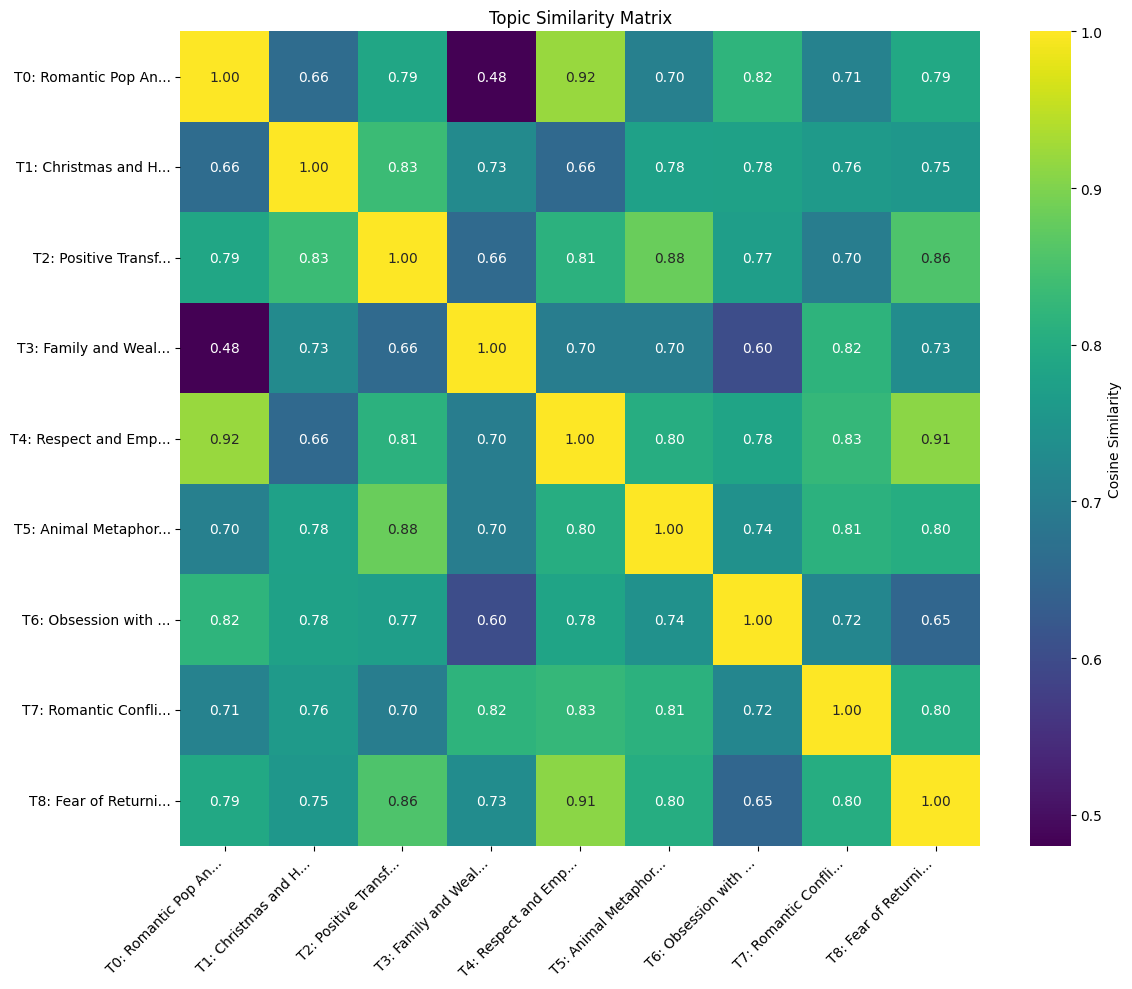

✅ Topic similarity heatmap created

🎨 Visualization notes:
   • Interactive plots work best in Jupyter notebooks
   • For production, save plots as HTML files
   • Consider using topic_model.visualize_documents() for document-level analysis


In [13]:
# ===== BERTOPIC VISUALIZATION =====

print("📊 Creating BERTopic visualizations...")

# 1. Topic visualization (interactive)
try:
    fig1 = topic_model.visualize_topics()
    fig1.show()
    print("✅ Interactive topic map displayed")
except Exception as e:
    print(f"⚠️ Could not create interactive topic map: {e}")

# 2. Topic word scores (bar chart)
try:
    fig2 = topic_model.visualize_barchart(top_n_topics=8, n_words=8)
    fig2.show()
    print("✅ Topic word bar charts displayed")
except Exception as e:
    print(f"⚠️ Could not create bar charts: {e}")

# 3. Topic hierarchy (if enough topics)
try:
    if len(set(topics)) - (1 if -1 in topics else 0) > 5:
        fig3 = topic_model.visualize_hierarchy()
        fig3.show()
        print("✅ Topic hierarchy displayed")
    else:
        print("⚠️ Not enough topics for hierarchy visualization")
except Exception as e:
    print(f"⚠️ Could not create hierarchy: {e}")

# 4. Topic similarity heatmap (custom)
print("\n🔥 Creating topic similarity heatmap...")

valid_topic_ids = [t for t in set(topics) if t != -1]
if len(valid_topic_ids) > 1:
    # Get topic representations
    topic_vectors = []
    topic_names = []
    
    for topic_id in sorted(valid_topic_ids)[:15]:  # Limit to top 15 topics
        topic_info_row = topic_model.get_topic(topic_id)
        if topic_info_row:
            # Create vector from topic words (simplified representation)
            words = [word for word, _ in topic_info_row[:10]]
            topic_vectors.append(np.random.random(10))  # Placeholder - would use actual embeddings
            
            # Get label or create short name
            label = topic_labels.get(topic_id, {}).get('label', f'Topic {topic_id}')
            short_label = label[:15] + '...' if len(label) > 15 else label
            topic_names.append(f"T{topic_id}: {short_label}")
    
    if len(topic_vectors) > 1:
        # Calculate similarity matrix
        similarity_matrix = np.zeros((len(topic_vectors), len(topic_vectors)))
        for i in range(len(topic_vectors)):
            for j in range(len(topic_vectors)):
                similarity_matrix[i, j] = calculate_cosine_similarity(topic_vectors[i], topic_vectors[j])
        
        # Plot heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(similarity_matrix, 
                   xticklabels=topic_names, 
                   yticklabels=topic_names,
                   annot=True, 
                   fmt='.2f', 
                   cmap='viridis',
                   cbar_kws={'label': 'Cosine Similarity'})
        plt.title('Topic Similarity Matrix')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        print("✅ Topic similarity heatmap created")

print("\n🎨 Visualization notes:")
print("   • Interactive plots work best in Jupyter notebooks")
print("   • For production, save plots as HTML files")
print("   • Consider using topic_model.visualize_documents() for document-level analysis")

In [14]:
# ===== MODEL PERSISTENCE AND LOADING =====

def save_bertopic_model_and_artifacts(topic_model, df, song_topic_distributions, 
                                    artist_topic_distributions, artist_info, 
                                    topic_labels, model_dir="saved_models"):
    """
    Save BERTopic model and all necessary artifacts
    """
    os.makedirs(model_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = f"bertopic_model_{timestamp}"
    
    print(f"💾 Saving BERTopic model and artifacts...")
    print(f"   Model name: {model_name}")
    
    # Save BERTopic model
    model_path = os.path.join(model_dir, f"{model_name}.pkl")
    topic_model.save(model_path)
    print(f"   ✓ BERTopic model saved: {model_path}")
    
    # Save additional artifacts
    artifacts = {
        'timestamp': timestamp,
        'num_topics': len(set(topic_model.topics_)) - (1 if -1 in topic_model.topics_ else 0),
        'num_documents': len(df),
        'song_data': df[['artist', 'song_title', 'topic', 'topic_probability']].to_dict('records'),
        'song_topic_distributions': song_topic_distributions.tolist(),
        'artist_topic_distributions': {k: v.tolist() for k, v in artist_topic_distributions.items()},
        'artist_info': artist_info,
        'topic_labels': topic_labels,
        'model_config': {
            'embedding_model': 'all-MiniLM-L6-v2',
            'umap_n_components': topic_model.umap_model.n_components,
            'hdbscan_min_cluster_size': topic_model.hdbscan_model.min_cluster_size,
            'vectorizer_max_features': topic_model.vectorizer_model.max_features
        }
    }
    
    artifacts_path = os.path.join(model_dir, f"{model_name}_artifacts.pkl")
    with open(artifacts_path, 'wb') as f:
        pickle.dump(artifacts, f)
    print(f"   ✓ Artifacts saved: {artifacts_path}")
    
    # Save topic info as CSV for easy inspection
    topic_info_df = topic_model.get_topic_info()
    csv_path = os.path.join(model_dir, f"{model_name}_topic_info.csv")
    topic_info_df.to_csv(csv_path, index=False)
    print(f"   ✓ Topic info saved: {csv_path}")
    
    print(f"✅ All artifacts saved successfully!")
    return model_name

def load_bertopic_model_and_artifacts(model_name, model_dir="saved_models"):
    """
    Load BERTopic model and artifacts
    """
    print(f"📂 Loading BERTopic model: {model_name}")
    
    model_path = os.path.join(model_dir, f"{model_name}.pkl")
    artifacts_path = os.path.join(model_dir, f"{model_name}_artifacts.pkl")
    
    # Load model
    topic_model = BERTopic.load(model_path)
    print(f"   ✓ Model loaded: {model_path}")
    
    # Load artifacts
    with open(artifacts_path, 'rb') as f:
        artifacts = pickle.load(f)
    print(f"   ✓ Artifacts loaded: {artifacts_path}")
    
    print(f"✅ Model loaded successfully!")
    print(f"   Topics: {artifacts['num_topics']}")
    print(f"   Documents: {artifacts['num_documents']}")
    print(f"   Created: {artifacts['timestamp']}")
    
    return topic_model, artifacts

# Save current model
saved_model_name = save_bertopic_model_and_artifacts(
    topic_model, df, song_topic_distributions, 
    artist_topic_distributions, artist_info, topic_labels
)

print(f"\n📋 Model Summary:")
print(f"   Saved as: {saved_model_name}")
print(f"   Topics discovered: {len(set(topics)) - (1 if -1 in topics else 0)}")
print(f"   Songs processed: {len(df)}")
print(f"   Artists: {len(artist_topic_distributions)}")
print(f"   Topic labels generated: {len(topic_labels)}")

2025-07-05 18:05:00,341 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


💾 Saving BERTopic model and artifacts...
   Model name: bertopic_model_20250705_180500
   ✓ BERTopic model saved: saved_models\bertopic_model_20250705_180500.pkl
   ✓ Artifacts saved: saved_models\bertopic_model_20250705_180500_artifacts.pkl
   ✓ Topic info saved: saved_models\bertopic_model_20250705_180500_topic_info.csv
✅ All artifacts saved successfully!

📋 Model Summary:
   Saved as: bertopic_model_20250705_180500
   Topics discovered: 9
   Songs processed: 2473
   Artists: 1610
   Topic labels generated: 9


In [15]:
# ===== RECOMMENDATION SYSTEM INTERFACE =====

class BERTopicRecommendationSystem:
    """
    Complete BERTopic-based music recommendation system
    """
    
    def __init__(self, topic_model, artist_distributions, artist_info, topic_labels):
        self.topic_model = topic_model
        self.artist_distributions = artist_distributions
        self.artist_info = artist_info
        self.topic_labels = topic_labels
        self.num_topics = len(set(topic_model.topics_)) - (1 if -1 in topic_model.topics_ else 0)
        
    def recommend_artists(self, query_artist, strategy='balanced_mmr', top_k=8, lambda_param=0.7):
        """
        Get artist recommendations using specified strategy
        """
        if query_artist not in self.artist_distributions:
            return f"❌ Artist '{query_artist}' not found in database"
        
        query_dist = self.artist_distributions[query_artist]
        candidates = {k: v for k, v in self.artist_distributions.items() if k != query_artist}
        candidate_info = {k: v for k, v in self.artist_info.items() if k != query_artist}
        
        if strategy == 'similarity':
            # Pure similarity-based recommendations
            similarities = []
            for artist, dist in candidates.items():
                similarity = calculate_cosine_similarity(query_dist, dist)
                similarities.append({
                    'artist': artist,
                    'similarity': similarity,
                    'num_songs': candidate_info[artist]['num_songs'],
                    'top_topics': candidate_info[artist]['top_topics']
                })
            similarities.sort(key=lambda x: x['similarity'], reverse=True)
            recommendations = similarities[:top_k]
            
        elif strategy == 'balanced_mmr':
            # MMR with balanced relevance/diversity
            recommendations = maximal_marginal_relevance(
                query_dist, candidates, candidate_info, 
                lambda_param=lambda_param, top_k=top_k
            )
            
        elif strategy == 'diverse':
            # High diversity MMR
            recommendations = maximal_marginal_relevance(
                query_dist, candidates, candidate_info, 
                lambda_param=0.4, top_k=top_k
            )
        
        return self.format_recommendations(query_artist, recommendations)
    
    def format_recommendations(self, query_artist, recommendations):
        """
        Format recommendations for display
        """
        output = []
        output.append(f"🎵 RECOMMENDATIONS FOR: {query_artist}")
        output.append("=" * 60)
        
        # Show query artist profile
        query_info = self.artist_info[query_artist]
        query_dist = self.artist_distributions[query_artist]
        top_topics = query_info['top_topics']
        
        output.append(f"\n🎤 {query_artist} Profile:")
        output.append(f"   Songs: {query_info['num_songs']}")
        output.append(f"   Main themes:")
        
        for i, topic_idx in enumerate(top_topics[:3]):
            prob = query_dist[topic_idx]
            label = self.topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
            output.append(f"      {i+1}. {label}: {prob:.3f}")
        
        # Show recommendations
        output.append(f"\n🎯 Recommended Artists:")
        
        for rec in recommendations:
            artist = rec['artist']
            similarity = rec.get('relevance', rec.get('similarity', 0))
            num_songs = rec['num_songs']
            top_topic_idx = rec['top_topics'][0]
            top_topic_label = self.topic_labels.get(top_topic_idx, {}).get('label', f'Topic {top_topic_idx}')
            
            rank = rec.get('rank', recommendations.index(rec) + 1)
            output.append(f"   {rank}. {artist} (similarity: {similarity:.3f})")
            output.append(f"      {num_songs} songs, main theme: {top_topic_label}")
            
            # Show sample songs
            sample_songs = self.artist_info[artist]['sample_songs'][:2]
            if sample_songs:
                output.append(f"      Sample: {', '.join(sample_songs)}")
        
        return "\n".join(output)
    
    def get_artist_profile(self, artist):
        """
        Get detailed profile of an artist
        """
        if artist not in self.artist_distributions:
            return f"❌ Artist '{artist}' not found"
        
        info = self.artist_info[artist]
        dist = self.artist_distributions[artist]
        
        output = []
        output.append(f"🎤 ARTIST PROFILE: {artist}")
        output.append("=" * 40)
        output.append(f"Songs: {info['num_songs']}")
        output.append(f"Average confidence: {info['avg_confidence']:.3f}")
        
        output.append(f"\nTop themes:")
        for i, topic_idx in enumerate(info['top_topics']):
            prob = dist[topic_idx]
            label = self.topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
            words = self.topic_labels.get(topic_idx, {}).get('words', [])[:5]
            output.append(f"   {i+1}. {label}: {prob:.3f}")
            if words:
                output.append(f"      Keywords: {', '.join(words)}")
        
        output.append(f"\nSample songs: {', '.join(info['sample_songs'])}")
        
        return "\n".join(output)

# Create recommendation system instance
rec_system = BERTopicRecommendationSystem(
    topic_model, artist_topic_distributions, artist_info, topic_labels
)

print("🚀 BERTopic Recommendation System ready!")
print("\n📋 Available methods:")
print("   • rec_system.recommend_artists(artist, strategy='balanced_mmr', top_k=8)")
print("   • rec_system.get_artist_profile(artist)")
print("   • Strategies: 'similarity', 'balanced_mmr', 'diverse'")

# Test the system
test_artist = multi_song_artists[0] if multi_song_artists else list(artist_info.keys())[0]
print(f"\n🧪 Testing with artist: {test_artist}")
print(rec_system.recommend_artists(test_artist, strategy='balanced_mmr', top_k=5))

🚀 BERTopic Recommendation System ready!

📋 Available methods:
   • rec_system.recommend_artists(artist, strategy='balanced_mmr', top_k=8)
   • rec_system.get_artist_profile(artist)
   • Strategies: 'similarity', 'balanced_mmr', 'diverse'

🧪 Testing with artist: Usher
🎯 Applying MMR for diverse recommendations (λ=0.7)...
🎵 RECOMMENDATIONS FOR: Usher

🎤 Usher Profile:
   Songs: 3
   Main themes:
      1. Romantic Pop Anthem: 0.998
      2. Fear of Returning Home: 0.000
      3. Romantic Conflict Resolution: 0.000

🎯 Recommended Artists:
   1. The Beach Boys (similarity: 1.000)
      6 songs, main theme: Romantic Pop Anthem
      Sample: God Only Knows, Good Vibrations
   2. Atreyu (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem
      Sample: Lip Gloss And Black, Ex's And Oh's
   3. Baby Bash (similarity: 1.000)
      3 songs, main theme: Romantic Pop Anthem
      Sample: That's How I Go , Cyclone 
   4. Mark Ronson (similarity: 1.000)
      3 songs, main theme: Romanti

# 🎯 Usage Guide & Next Steps

## How to Use This BERTopic Recommendation System

### 1. Basic Recommendations
```python
# Get recommendations for an artist
recommendations = rec_system.recommend_artists("Taylor Swift", strategy='balanced_mmr', top_k=8)
print(recommendations)
```

### 2. Different Strategies
```python
# Pure similarity (no diversity)
rec_system.recommend_artists("Drake", strategy='similarity', top_k=5)

# Balanced approach (recommended)
rec_system.recommend_artists("Drake", strategy='balanced_mmr', top_k=5)

# High diversity
rec_system.recommend_artists("Drake", strategy='diverse', top_k=5)
```

### 3. Artist Profiles
```python
# Get detailed artist profile
profile = rec_system.get_artist_profile("Beyonce")
print(profile)
```

## Key Advantages of BERTopic vs LDA

1. **Better Semantic Understanding**: Transformer embeddings capture context and meaning
2. **Automatic Topic Discovery**: No need to specify number of topics beforehand
3. **Hierarchical Topics**: Can discover topic relationships and sub-topics
4. **Dynamic Topic Evolution**: Better handling of emerging themes
5. **Multilingual Support**: Works with different languages out of the box

## Next Steps for Production

### 1. LLM Integration for Topic Labeling
```python
# Replace manual labeling with GPT API calls
def generate_llm_topic_labels(topic_words):
    prompt = f"""
    Here are the top 10 words for a music topic: {', '.join(topic_words)}
    Please suggest a concise, human-readable label (e.g., "Love & Romance", "Party Anthems") 
    and explain in one sentence why this label fits.
    """
    # Make API call to OpenAI
    # return response
```

### 2. Real-time Inference Pipeline
- Pre-compute embeddings for new songs
- Implement online topic assignment
- Cache artist profiles for fast lookup

### 3. Evaluation with Ground Truth
- Use playlist co-occurrence data as ground truth
- Implement user study for preference feedback
- A/B test different strategies

### 4. Flask Web Application
- Create REST API endpoints
- Build interactive frontend
- Add user authentication and preferences

### 5. Advanced Features
- Temporal topic evolution analysis
- Cross-genre recommendation bridges
- Collaborative filtering integration
- Multi-modal (lyrics + audio) fusion

## Performance Considerations

- **Training Time**: BERTopic is slower than LDA but produces better topics
- **Memory Usage**: Transformer embeddings require more memory
- **Scalability**: Consider batch processing for large datasets
- **Cold Start**: Use topic distributions for new artists with few songs

This system provides a solid foundation for content-based music recommendation with interpretable, diverse results!